In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [64]:
R_vector = np.array([1,2,3])
R_vector = R_vector/np.sqrt(np.dot(R_vector,R_vector))

In [124]:
pauli_x = np.array([[0,1],[1,0]])
pauli_y = np.array([[0,-1j],[1j,0]])
pauli_z = np.array([[1,0],[0,-1]])

pauli_vector = np.array([pauli_x,pauli_y,pauli_z])

def generate_pauli(arr):
    return np.array([pauli_vector[0]*arr[0],pauli_vector[1]*arr[1],pauli_vector[2]*arr[2]])

def element_pauli(arr):
    return np.array([arr[0][0,1],np.abs(arr[1][0,1]),np.abs(arr[2][0,0])])
    
direc_pauli = generate_pauli(R_vector)

In [119]:
theta=20

unit = np.exp(1j*theta*0.5*direc_pauli)

In [120]:
pos_vec = np.array([2,2,7])
pos_vec = pos_vec/np.sqrt(np.dot(pos_vec,pos_vec))

pos_pauli = generate_pauli(pos_vec)

In [121]:
pos_pauli[0][0,0]

np.complex128(0j)

In [122]:
rot_vec = unit @ pos_pauli
a = generate_pauli(rot_vec)
result = element_pauli(a)

In [123]:
a

array([[[-0.        +0.j        ,  0.26490647+0.j        ],
        [ 0.26490647+0.j        , -0.        +0.j        ]],

       [[ 0.        +0.j        , -0.26490647+0.j        ],
        [-0.26490647+0.j        ,  0.        +0.j        ]],

       [[ 0.26300382-0.88908836j, -0.        +0.j        ],
        [ 0.        +0.j        ,  0.26300382+0.88908836j]]])

c:\Users\sky12\anaconda3\envs\Workspace\Lib\site-packages\mpl_toolkits\mplot3d\axes3d.py:3305: ComplexWarning: Casting complex values to real discards the imaginary part
  UVW = np.column_stack(input_args[3:]).astype(float)


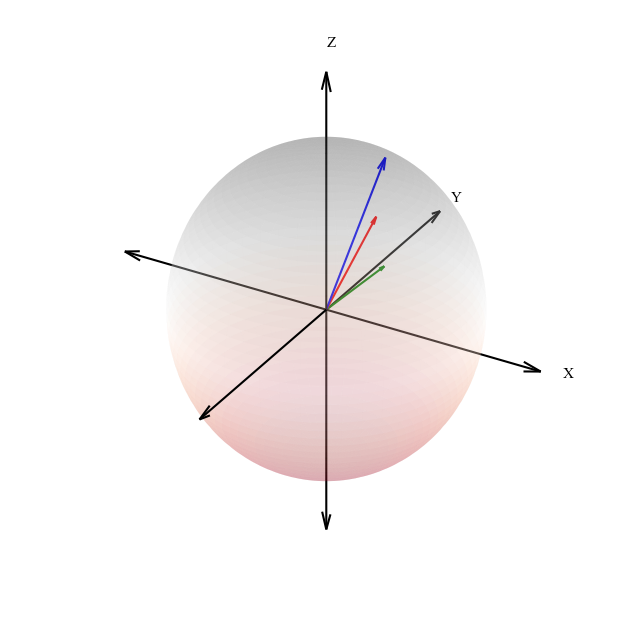

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({'font.size': 11})

# Make data
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)                                       
radius = 1.0
x = radius * np.outer(np.cos(u), np.sin(v))
y = radius * np.outer(np.sin(u), np.sin(v))
z = radius * np.outer(np.ones(np.size(u)), np.cos(v))

# --- 원점에서 시작하는 사용자 정의 축 그리기 ---

axis_length = 1.5 * radius # 축 길이를 구 반지름보다 약간 길게 설정
arrow_length_ratio = 0.08 # 화살표 머리 크기 비율 (quiver 사용 시)

# X축 (빨간색)
ax.quiver(0, 0, 0, axis_length, 0, 0, color='black', arrow_length_ratio=arrow_length_ratio, label='X')
ax.quiver(0, 0, 0, -axis_length, 0, 0, color='black', arrow_length_ratio=arrow_length_ratio) # 음의 방향
ax.text(axis_length * 1.1, 0, 0, 'X', color='black')

# Y축 (녹색)
ax.quiver(0, 0, 0, 0, axis_length, 0, color='black', arrow_length_ratio=arrow_length_ratio, label='Y')
ax.quiver(0, 0, 0, 0, -axis_length, 0, color='black', arrow_length_ratio=arrow_length_ratio) # 음의 방향
ax.text(0, axis_length * 1.1, 0, 'Y', color='black')

# Z축 (파란색)
ax.quiver(0, 0, 0, 0, 0, axis_length, color='black', arrow_length_ratio=arrow_length_ratio, label='Z')
ax.quiver(0, 0, 0, 0, 0, -axis_length, color='black', arrow_length_ratio=arrow_length_ratio) # 음의 방향
ax.text(0, 0, axis_length * 1.1, 'Z', color='black')

ax.quiver(0,0,0,R_vector[0],R_vector[1],R_vector[2],arrow_length_ratio=0.08,color='red')
ax.quiver(0,0,0,pos_vec[0],pos_vec[1],pos_vec[2],arrow_length_ratio=0.08,color='blue')
ax.quiver(0,0,0,result[0],result[1],result[2],arrow_length_ratio=0.08,color='green')

# Plot the surface
ax.plot_surface(x, y, z, cmap='RdGy', alpha = 0.2)
ax.set_box_aspect([1, 1, 1])

ax.set_axis_off()

plt.show()

In [9]:
from qutip import *

In [10]:
b = Bloch()

xz = np.zeros(20)
yz = [0.5*np.sin(th) for th in np.linspace(0, np.pi, 20)]
zz = [0.5*np.cos(th) for th in np.linspace(0, np.pi, 20)]

b.add_points([xz, yz, zz])

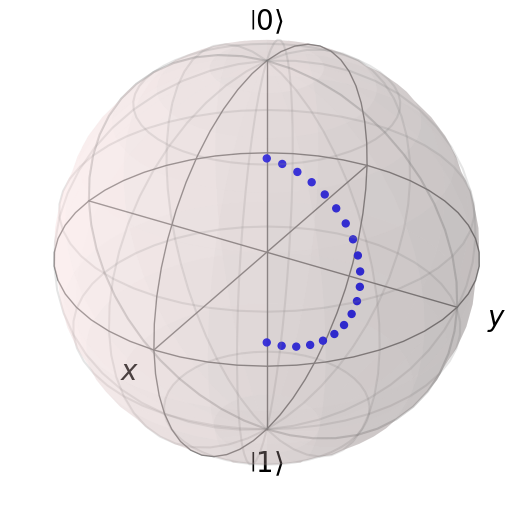

In [11]:
b.show()

In [12]:
x = np.array([[1, 2, 3, 4, 5]])
print(Qobj(x))

Quantum object: dims=[[1], [5]], shape=(1, 5), type='bra', dtype=Dense
Qobj data =
[[1. 2. 3. 4. 5.]]


In [19]:
asdf

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.57797185+0.j       0.349228  +0.349228j]
 [0.349228  -0.349228j 0.42202815+0.j      ]]

In [45]:
asdf = coherent_dm(2,0.1+0.2j)
Nup_asdf = asdf.full()

In [46]:
type(asdf)

qutip.core.qobj.Qobj

In [49]:
c = Bloch()

#pointz = 2*asdf[0][0] - 1
#if pointz == 1 - 2*asdf[1][1]:
#    print("correct")
#pointx = 2*0.349
#pointy = 2*0.349

pointx = expect(sigmax(), asdf)
pointy = expect(sigmay(), asdf)
pointz = expect(sigmaz(), asdf)


c.add_points([pointx, pointy, pointz])
c.add_vectors([pointx, pointy, pointz])

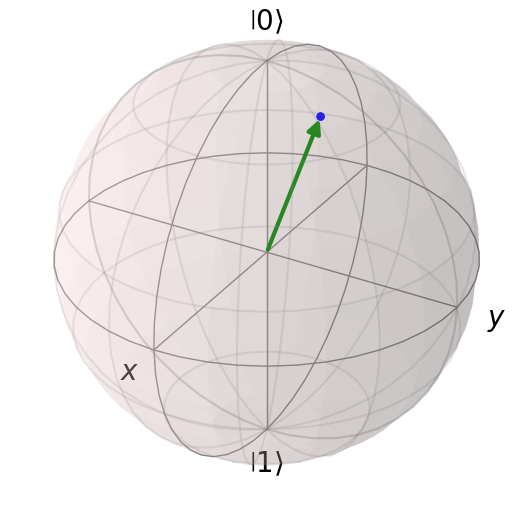

In [50]:
c.show()